{'剧情': 186, '犯罪': 43, '历史': 19, '战争': 20, '纪录': 24, '音乐': 24, '喜剧': 47, '爱情': 48, '动画': 58, '家庭': 30, '奇幻': 48, '动作': 44, '惊悚': 37, '冒险': 48, '科幻': 27, '西部': 4, '恐怖': 5, '悬疑': 16}


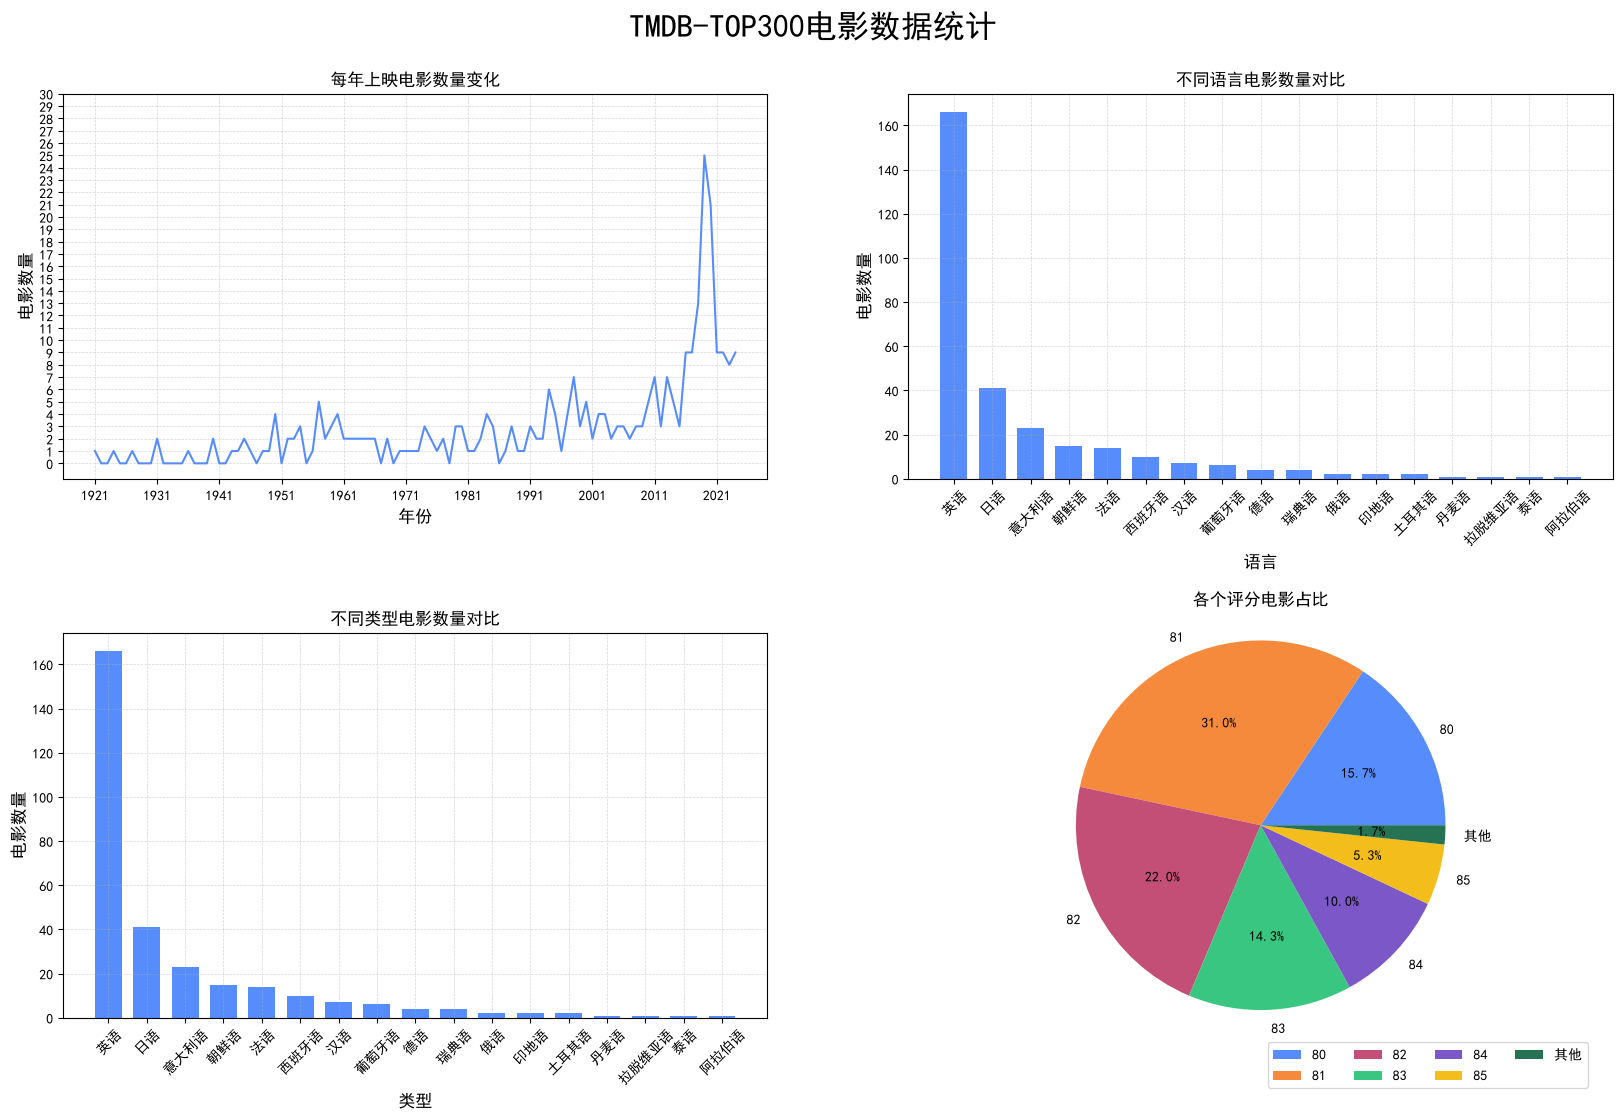

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.mpl_axes import Axes


#核心是数据的处理


#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi=100)
fig.suptitle('TMDB-TOP300电影数据统计',fontsize=23,x=0.5,y=0.95)
fig.subplots_adjust(hspace=0.4,wspace=0.2)

axes1:Axes=ax[0][0]
axes2:Axes=ax[0][1]
axes3:Axes=ax[1][0]
axes4:Axes=ax[1][1]

#加载数据
data = pd.read_csv('data/movies.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})

data.isnull().sum()
data['年份']=data['年份'].fillna(data['上映时间'].str[0:4])
year_count = data.groupby('年份')['年份'].count()
#组装数据
min_year = year_count.index.min()
max_year = year_count.index.max()

x = [i for i in range(min_year,max_year)]

y = [year_count.get(i,0) for i in x]

axes1.plot(x,y)
axes1.set_title('每年上映电影数量变化')
axes1.set_xlabel('年份',fontsize = 12)
axes1.set_ylabel('电影数量',fontsize = 12)
axes1.set_xticks(x[::10])
y_ticks = [i for i in range(0,31)]
axes1.set_yticks(y_ticks)
axes1.grid(linestyle= '--',alpha=0.5)

#需求2:统计对比不同语言的电影数量,做成柱状图
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)
x_language = language_count.index.tolist()
y_language = language_count.values.tolist()

axes2.bar(x_language,y_language,width
=0.7)
axes2.set_title("不同语言电影数量对比")
axes2.set_xlabel('语言',fontsize = 12)
axes2.set_ylabel('电影数量',fontsize = 12)
axes2.grid(linestyle='--',alpha=0.5)
axes2.tick_params(axis='x',rotation=45)

#需求三:统计对比不同类型的电影数量柱状图
#获取不同类型电影数量
type_count = {}
for types in data['类型'].str.split(','):
    for type in types:
        if type not in type_count:
            type_count[type] = 1
        else:
            type_count[type] += 1
print(type_count)

axes3.bar(x_language,y_language,width
=0.7)
axes3.set_title("不同类型电影数量对比")
axes3.set_xlabel('类型',fontsize = 12)
axes3.set_ylabel('电影数量',fontsize = 12)
axes3.grid(linestyle='--',alpha=0.5)
axes3.tick_params(axis='x',rotation=45)

#需求四统计各个评分的电影占比饼状图
#按占比展示,合并小数据
score_count = data.groupby('评分')['评分'].count()
total = score_count.sum()
large_scores = score_count.loc[score_count>=total*0.02]
small_scores = score_count.loc[score_count<total*0.02]

if small_scores.shape[0]>0:
    large_scores['其他'] = small_scores.sum()


axes4.set_title('各个评分电影占比',y=1.05)
scores =  large_scores.index.tolist()
score_values =  large_scores.values.tolist()
axes4.pie(score_values,labels=scores,autopct='%1.1f%%',shadow=False,startangle=0,radius=1.2)
axes4.legend(loc='lower left', bbox_to_anchor=(0.5, -0.2),ncol=4)

plt.savefig('data/TMDB-TOP300.png')
plt.show()





